In [ ]:
library(hdf5r)
library(Seurat)
library(ggplot2)
library(stringr)
#####feature plot
library(Seurat)
library(ggplot2)
library(cowplot)
library(dplyr)
library(tidyr)
library(stringr)
library(viridis)
library(reshape2)
library(patchwork)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library(stringr)
library(Seurat)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)

In [33]:
###fnm S4
##human
drds <- "/DATA/User/liqian7/pienapple/24AS_fig_add/00DATA/04fn_data/04AS_ud/"
n=0
for(s in Sys.glob(file.path(drds,"*_uc.RDS"))){
    n=n+1
    key <- gsub("_uc.RDS","",basename(s))
    sp <- readRDS(paste0(drds,key,"_uc.RDS"))
    m <- sp@meta.data
    m$rown <- paste0(key,m$rown)
    if(n==1){
        m1 <- m
    }
    else{
        m1 <- rbind(m1,m)
    }
}

In [34]:
head(m1)

,orig.ident,nCount_RNA,nFeature_RNA,area,x,y,rown,ann1,layer,ann2,⋯,score_ssgsea,iterms,stage_ann,stage_ann_peaks,level,ns_stage,ns_stage_peak,as_stage,adventitia,stage_clinical
,<fct>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
10,SeuratProject,77,43,310,14511.11,9796.552,A05862E3_110,Fib,69.509883,Fib,⋯,0.1140135,AShuman,stage1,stage1,good,stage1,stage1,stage1,none,late
16,SeuratProject,335,203,665,17349.14,15421.743,A05862E3_116,T cell,31.880386,NKT,⋯,0.1140135,AShuman,stage1,stage1,good,stage1,stage1,stage1,none,late
20,SeuratProject,99,62,415,15138.55,10162.549,A05862E3_120,Fib,52.971178,Fib,⋯,0.1140135,AShuman,stage1,stage1,good,stage1,stage1,stage1,none,late
24,SeuratProject,124,79,1429,13857.24,10675.849,A05862E3_124,mSMC,100.000000,mSMC,⋯,0.1140135,AShuman,stage1,stage1,good,stage1,stage1,stage1,none,late
25,SeuratProject,232,148,252,15174.37,15018.024,A05862E3_125,mSMC,96.334838,DC,⋯,0.1140135,AShuman,stage1,stage1,good,stage1,stage1,stage1,none,late
27,SeuratProject,92,66,2070,16442.67,9226.714,A05862E3_127,EC,2.146506,NKT,⋯,0.1140135,AShuman,stage1,stage1,good,stage1,stage1,stage1,none,late


In [35]:
m1$ann2 <- str_replace(m1$ann2,"EC_1","iEC")
m1$ann2 <- str_replace(m1$ann2,"EC_2","vEC")

In [36]:
cols2 <- c('Fib'="#8b4a4b",'SMC'="#1f78b4",'mSMC'="#A1CFFA",'Monocyte'="#E9B3FB",'Macro'="#df65b0",'DC'="#A5158C",'Mast_cell'="#FA26A0",'B_cell'="#EF7722",'plasma cell'="#FCB53B",'NKT'="#ce1256",'iEC'="#238b45",'vEC'="#06D001")
m1$ann2 <- factor(m1$ann2,levels = c('Fib','SMC','mSMC','Monocyte','Macro','DC','Mast_cell','B_cell','plasma cell','NKT','iEC','vEC'))
cell <- c('Fib','SMC','mSMC','Monocyte','Macro','DC','Mast_cell','B_cell','plasma cell','NKT','iEC','vEC')

In [ ]:
mer1 <- m1[which(m1$layer!=0&m1$sample=="save"&m1$adventitia=="yes"),]
mer2 <- mer1[which(mer1$ann2!="NA"),]

In [46]:
stage1 <- subset(mer2,subset = rown%in%sample(mer2[which(mer2$stage_ann=="stage1"),]$rown, 91653))
stage2 <- subset(mer2,subset = rown%in%sample(mer2[which(mer2$stage_ann=="stage2"),]$rown, 91653))
stage3 <- subset(mer2,subset = rown%in%sample(mer2[which(mer2$stage_ann=="stage3"),]$rown, 91653))
stage4 <- subset(mer2,subset = rown%in%sample(mer2[which(mer2$stage_ann=="stage4"),]$rown, 91653))

In [48]:
mer3 <- rbind(stage1,stage2,stage3,stage4)

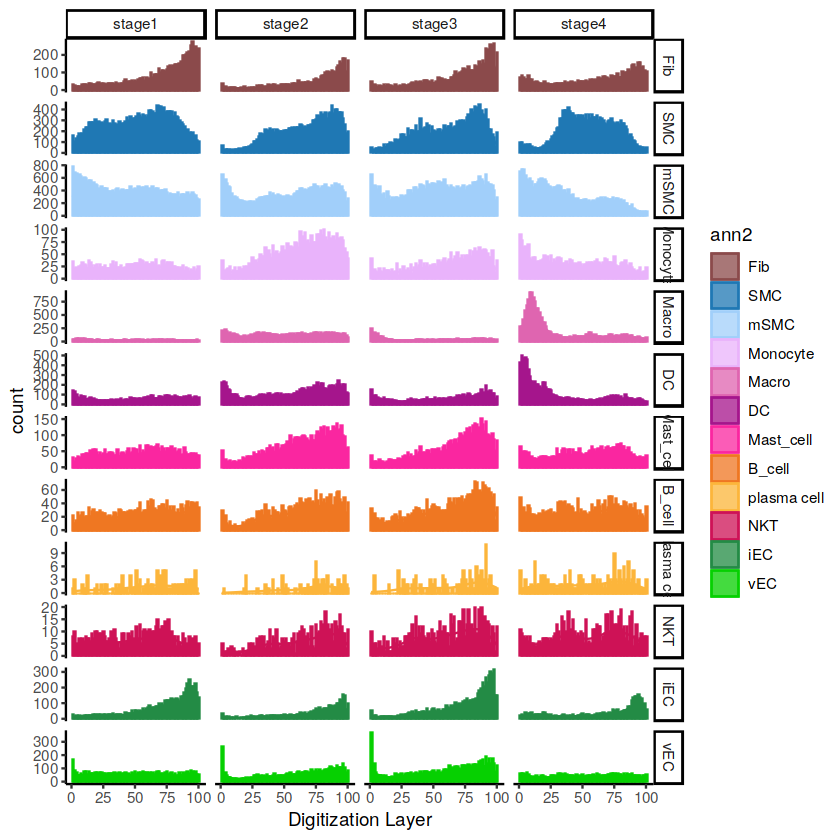

In [49]:
p <- gghistogram(mer3,
            x='layer',
            add=NULL,
            rug = FALSE,
            color = "ann2",
            fill = "ann2",
            #palette = c("#0fb9b1","#f7b731","#8854d0"),
            bins = 80,
            add_density = TRUE,
            xlab = "Digitization Layer")+facet_wrap(ann2~ stage_ann, scales = "free_y", ncol = 4)+
scale_color_manual(values = cols2)+scale_fill_manual(values = cols2)+facet_grid(ann2~ stage_ann, scales="free_y", space="free_x")+
theme_classic()
p
ggsave("S4_ann2_celltype_save&adventitia.pdf",p,width = 12,height = 10)